In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("car.data")

In [3]:
df

,vhigh,vhigh.1,2,2.1,small,low,unacc
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc
...,...,...,...,...,...,...,...
1722,low,low,5more,more,med,med,good
1723,low,low,5more,more,med,high,vgood
1724,low,low,5more,more,big,low,unacc
1725,low,low,5more,more,big,med,good


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1727 entries, 0 to 1726
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   vhigh    1727 non-null   object
 1   vhigh.1  1727 non-null   object
 2   2        1727 non-null   object
 3   2.1      1727 non-null   object
 4   small    1727 non-null   object
 5   low      1727 non-null   object
 6   unacc    1727 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


In [4]:
col_names = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']

In [5]:
df.columns = col_names

In [6]:
df

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc
...,...,...,...,...,...,...,...
1722,low,low,5more,more,med,med,good
1723,low,low,5more,more,med,high,vgood
1724,low,low,5more,more,big,low,unacc
1725,low,low,5more,more,big,med,good


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1727 entries, 0 to 1726
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1727 non-null   object
 1   maint     1727 non-null   object
 2   doors     1727 non-null   object
 3   persons   1727 non-null   object
 4   lug_boot  1727 non-null   object
 5   safety    1727 non-null   object
 6   class     1727 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


In [8]:
df.describe(include='all').T

,count,unique,top,freq
buying,1727,4,high,432
maint,1727,4,high,432
doors,1727,4,3,432
persons,1727,3,4,576
lug_boot,1727,3,med,576
safety,1727,3,med,576
class,1727,4,unacc,1209


In [9]:
for col in col_names:
  print(df[col].value_counts())

buying
high     432
med      432
low      432
vhigh    431
Name: count, dtype: int64
maint
high     432
med      432
low      432
vhigh    431
Name: count, dtype: int64
doors
3        432
4        432
5more    432
2        431
Name: count, dtype: int64
persons
4       576
more    576
2       575
Name: count, dtype: int64
lug_boot
med      576
big      576
small    575
Name: count, dtype: int64
safety
med     576
high    576
low     575
Name: count, dtype: int64
class
unacc    1209
acc       384
good       69
vgood      65
Name: count, dtype: int64


In [10]:
df[df.duplicated()]

,buying,maint,doors,persons,lug_boot,safety,class


In [11]:
from sklearn.preprocessing import OrdinalEncoder
enc = OrdinalEncoder()
df['buying'] = enc.fit_transform(df[['buying']])
df['doors'] = enc.fit_transform(df[['doors']])
df['persons'] = enc.fit_transform(df[['persons']])
df['maint'] = enc.fit_transform(df[['maint']])
df['lug_boot'] = enc.fit_transform(df[['lug_boot']])
df['safety'] = enc.fit_transform(df[['safety']])
df['class'] = enc.fit_transform(df[['class']])

In [12]:
df

,buying,maint,doors,persons,lug_boot,safety,class
0,3.0,3.0,0.0,0.0,2.0,2.0,2.0
1,3.0,3.0,0.0,0.0,2.0,0.0,2.0
2,3.0,3.0,0.0,0.0,1.0,1.0,2.0
3,3.0,3.0,0.0,0.0,1.0,2.0,2.0
4,3.0,3.0,0.0,0.0,1.0,0.0,2.0
...,...,...,...,...,...,...,...
1722,1.0,1.0,3.0,2.0,1.0,2.0,1.0
1723,1.0,1.0,3.0,2.0,1.0,0.0,3.0
1724,1.0,1.0,3.0,2.0,0.0,1.0,2.0
1725,1.0,1.0,3.0,2.0,0.0,2.0,1.0


In [13]:
x = df.iloc[:,0:-1]
y = df.iloc[:,-1]

In [14]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state = 0, test_size = 0.2)

In [15]:
from sklearn.ensemble import RandomForestClassifier
clf1 = RandomForestClassifier()
clf1.fit(x_train, y_train)

RandomForestClassifier()

In [16]:
from sklearn.metrics import accuracy_score
pred = clf1.predict(x_test)
accuracy_score(pred, y_test)

0.9682080924855492

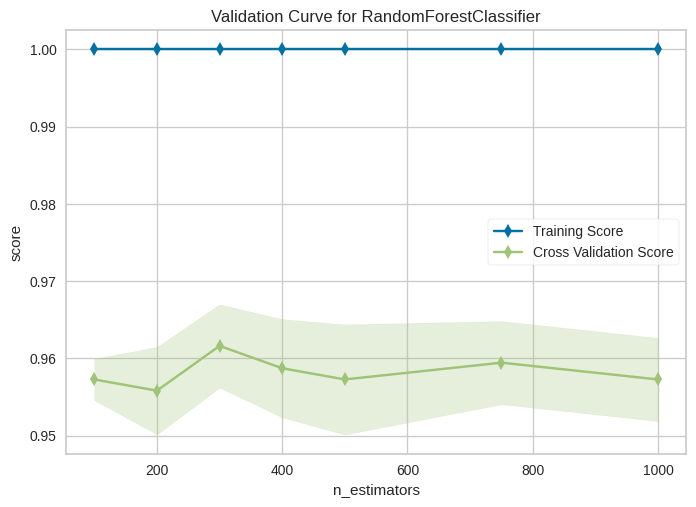

ValidationCurve(ax=<Axes: title={'center': 'Validation Curve for RandomForestClassifier'}, xlabel='n_estimators', ylabel='score'>,
                cv=3, estimator=RandomForestClassifier(),
                param_name='n_estimators',
                param_range=array([ 100,  200,  300,  400,  500,  750, 1000]),
                scoring='accuracy')


In [18]:
from yellowbrick.model_selection import validation_curve
num_est = [100,200,300,400, 500, 750, 1000]
print(validation_curve(RandomForestClassifier(), X = x_train, y = y_train, param_name = 'n_estimators', param_range = num_est, scoring = 'accuracy', cv=3))

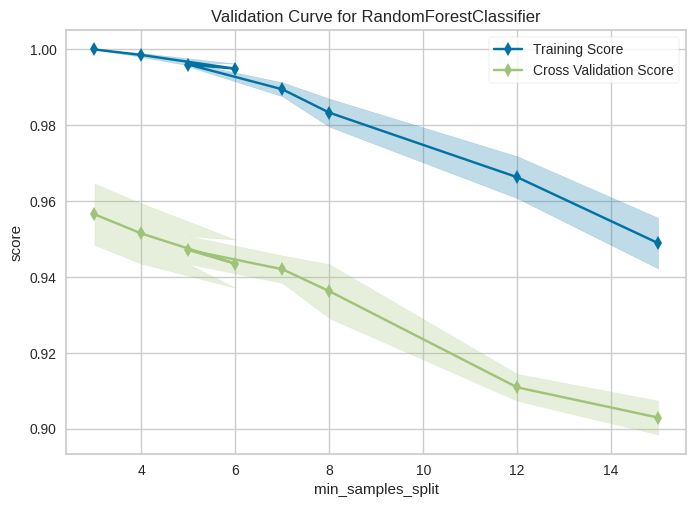

ValidationCurve(ax=<Axes: title={'center': 'Validation Curve for RandomForestClassifier'}, xlabel='min_samples_split', ylabel='score'>,
                cv=3, estimator=RandomForestClassifier(),
                param_name='min_samples_split',
                param_range=array([ 3,  4,  6,  5,  7,  8, 12, 15]),
                scoring='accuracy')


In [19]:
min_samples = [3,4,6,5,7,8,12,15]
print(validation_curve(RandomForestClassifier(), X = x_train, y = y_train, param_name = 'min_samples_split', param_range = min_samples, scoring = 'accuracy', cv=3))

In [22]:
clf2 = RandomForestClassifier(n_estimators = 300, min_samples_split = 3, max_depth = 15, random_state = 0)
clf2.fit(x_train, y_train)
pred = clf2.predict(x_test)
print(accuracy_score(pred, y_test))

0.9710982658959537


In [24]:
feature_scores = pd.Series(clf2.feature_importances_, index = x_train.columns).sort_values(ascending = False)
print(feature_scores)

safety      0.290660
persons     0.235181
buying      0.180601
maint       0.146289
lug_boot    0.083968
doors       0.063301
dtype: float64


Text(0.5, 0, 'Feature Importance Score')

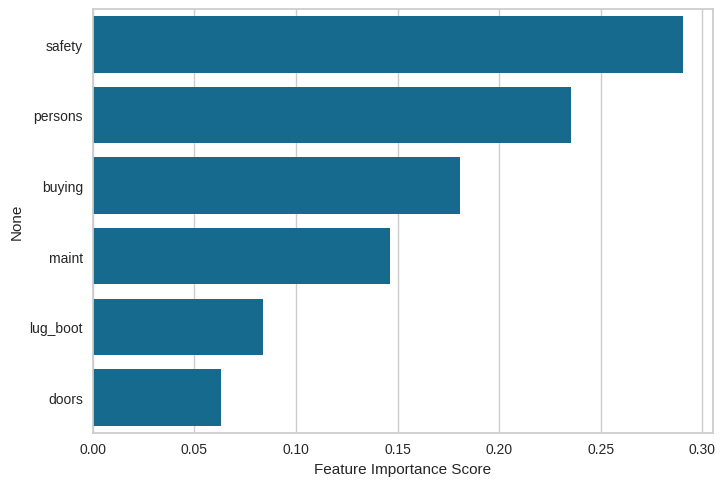

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.barplot(x = feature_scores, y = feature_scores.index)
plt.xlabel('Feature Importance Score')

In [26]:
clf3 = RandomForestClassifier()
xnew = df.drop(['doors', 'lug_boot', 'maint'], axis = 1)
ynew = df['class']
x_train1, x_test1, y_train1, y_test1 = train_test_split(xnew, ynew, random_state = 0, test_size = 0.2)
clf3.fit(x_train1, y_train1)
pred = clf3.predict(x_test1)
print(accuracy_score(pred, y_test1))

1.0
